In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 78.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 4.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=e9564d85a5367bb570a98402abed0968810393b6bab652ab7f0afc10d24696b5
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


## Grover's Algorithm: Conceptual and Code Explanation

Grover's algorithm is a quantum algorithm that offers a quadratic speedup over classical algorithms for searching an unsorted database. Given a function `f` that evaluates to 1 for a single 'marked' item `w` and 0 for all other items, Grover's algorithm aims to find `w`.

### The Oracle ($U_f$)

The core of the algorithm is a unitary operator called the 'oracle,' denoted as $U_f$. This oracle marks the target state `w` by applying a phase flip. Specifically:

*   $U_f |x\rangle = -|x\rangle$ if $x = w$ (the target state)
*   $U_f |x\rangle = |x\rangle$ if $x \neq w$ (any other state)

In the provided code, the `U` matrix represents this oracle. For a 3-qubit system, an 8x8 matrix is used. The target state `|000>` (which corresponds to the first element in the computational basis, index 0) is marked by having its corresponding diagonal element as -1, while all other diagonal elements are 1.

```python
U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0], # -1 for |000>
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])
```

To change the search target, you would modify this `U` matrix. For example, if you wanted to search for `|010>` (which is index 2 in binary), you would change `U[2][2]` to `-1` and `U[0][0]` to `1`.

### The Grover Diffusion Operator ($U_s$)

After applying the oracle, the algorithm uses a diffusion operator, $U_s$, also known as the 'Grover Diffusion Operator' or 'Amplitude Amplification' operator. This operator inverts the amplitudes about the average amplitude, effectively boosting the amplitude of the marked state and decreasing the amplitudes of the unmarked states. For an N-dimensional search space, $U_s = 2|s\rangle\langle s| - I$, where $|s\rangle$ is the uniform superposition state (all states have equal amplitude) and $I$ is the identity matrix.

In the code, `G_matrix` defines this operator for a 3-qubit system (N=8). Each element is scaled by `1/4.0` (since `2/N = 2/8 = 1/4`).

```python
G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1], # ...and so on
    # ... (rest of the matrix)
]))

G = Operator(G_matrix)
```

### The Algorithm Steps

1.  **Initialization**: All qubits are put into a uniform superposition state. This is achieved by applying a Hadamard gate (`h`) to each qubit. In the code:

```python
grover.h(0)
grover.h(1)
grover.h(2)
```

2.  **Iteration**: The oracle $U_f$ and the diffusion operator $U_s$ are applied a certain number of times. The optimal number of iterations for an N-item database with one marked item is approximately $\frac{\pi}{4}\sqrt{N}$. For 3 qubits, $N=2^3=8$, so the optimal number of iterations is $\frac{\pi}{4}\sqrt{8} \approx \frac{3.14}{4} \times 2.828 \approx 2.22$. The code uses 2 iterations, which is close to optimal.

```python
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
```

3.  **Measurement**: After the iterations, measuring the qubits will yield the marked state `w` with a high probability.

```python
grover.measure_all()
```

### Simulation and Visualization

The code then simulates the quantum circuit using `BasicSimulator` and visualizes the measurement results as a histogram, showing the probability distribution of outcomes.

```python
backend = BasicSimulator()
compiled = transpile(grover, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)
```

This setup effectively demonstrates Grover's algorithm for finding the state `|000>` within an 8-state space using Qiskit.

### Initialization of the Quantum State

**Is the initial state equivalent to $|s\rangle$? Yes, it is.**

In quantum computing, the initial state of all qubits is typically set to $|00\dots0\rangle$. For a 3-qubit system, this is $|000\rangle$.

**Conceptual Explanation:**

The uniform superposition state, $|s\rangle$, is defined as a state where every possible computational basis state has an equal amplitude. For $n$ qubits (and thus $N=2^n$ possible states), this is mathematically represented as:

$|s\rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle$

For 3 qubits, $N=2^3=8$, so:

$|s\rangle = \frac{1}{\sqrt{8}} (|000\rangle + |001\rangle + \dots + |111\rangle)$

**How the Python Code Achieves This:**

The code initializes the `grover` circuit and then applies a Hadamard gate (`h`) to each of the three qubits:

```python
grover = QuantumCircuit(3)

grover.h(0)
grover.h(1)
grover.h(2)
```

Let's trace what happens when a Hadamard gate is applied:

1.  **Start with $|0\rangle$**: If a single qubit is in the state $|0\rangle$, applying a Hadamard gate ($H$) transforms it into the superposition state $\frac{1}{\sqrt{2}}(|0\rangle + |1\rangle)$.

2.  **Applying to multiple qubits**: When you have multiple qubits, say initially in $|000\rangle$, and you apply a Hadamard gate to each one independently:

    *   $H|0\rangle_0 \otimes H|0\rangle_1 \otimes H|0\rangle_2$
    *   $= \left( \frac{1}{\sqrt{2}}(|0\rangle_0 + |1\rangle_0) \right) \otimes \left( \frac{1}{\sqrt{2}}(|0\rangle_1 + |1\rangle_1) \right) \otimes \left( \frac{1}{\sqrt{2}}(|0\rangle_2 + |1\rangle_2) \right)$
    *   $= \frac{1}{\sqrt{2^3}} (|000\rangle + |001\rangle + |010\rangle + |011\rangle + |100\rangle + |101\rangle + |110\rangle + |111\rangle)$
    *   $= \frac{1}{\sqrt{8}} \sum_{x=0}^{7} |x\rangle$

This is precisely the uniform superposition state $|s\rangle$. So, by applying Hadamard gates to all qubits, the code effectively prepares the circuit in the required uniform superposition state, which is the starting point for Grover's algorithm.

### Deeper Explanation of the U Operator (Oracle)

**Conceptually:**

The `U` operator is the heart of Grover's algorithm's 'search' capability. It's often called the **oracle** because it "knows" which state is the target without explicitly revealing it. Its sole job is to distinguish the target state from all other states by applying a **phase flip** to the target. All other states remain unchanged in phase.

Imagine you have a set of possibilities, and one of them is the 'correct' answer. The oracle doesn't tell you *what* the correct answer is, but if you *show* it the correct answer, it secretly tags it with a special sign (a negative phase).

Mathematically, for a single target state $|w\rangle$:

*   If the input state is the target $|w\rangle$, the oracle changes it to $-|w\rangle$.
*   If the input state is any other state $|x\rangle$ (where $x \neq w$), the oracle leaves it as $|x\rangle$.

This phase flip is crucial. Later, the Grover Diffusion Operator uses this negative phase to amplify the probability of measuring the target state.

**How the phase flip works in matrix form:**

A unitary operator that only applies phase changes to computational basis states (without mixing them) will always be a diagonal matrix. The elements on the diagonal correspond to the factors by which each basis state's amplitude is multiplied. For a phase flip, this factor is `-1`. For states that are not the target, the factor is `1` (meaning no change).

**Python Syntax and Implementation:**

The code defines the `U` operator using Qiskit's `Operator` class:

```python
U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])
```

1.  **`Operator([...])`**: This is how you define a custom unitary operator in Qiskit by providing its matrix representation. The matrix must be unitary for it to represent a valid quantum operation.

2.  **The 8x8 Matrix**: Since we are working with 3 qubits, there are $2^3 = 8$ possible computational basis states (from `|000>` to `|111>`). Each row and column in this 8x8 matrix corresponds to one of these basis states. By convention, they are ordered numerically:
    *   Row/Column 0: `|000>`
    *   Row/Column 1: `|001>`
    *   Row/Column 2: `|010>`
    *   ...
    *   Row/Column 7: `|111>`

3.  **Diagonal Elements**: The key observation is that this is a **diagonal matrix**. This means that when the operator `U` acts on a basis state $|x\rangle$, it simply multiplies $|x\rangle$ by the corresponding diagonal element $U_{xx}$ (it doesn't mix $|x\rangle$ with any other state $|y\rangle$).

    *   **`[-1, 0, 0, 0, 0, 0, 0, 0]`**: This first row (and column) corresponds to the state `|000>`. The `-1` in the top-left corner (index [0][0]) indicates that when `U` acts on `|000>`, its amplitude is multiplied by -1, thus applying the phase flip. This means the target state for this oracle is `|000>`.

    *   **`[0, 1, 0, ..., 0]`**: The second row (index [1][1]) has a `1` on the diagonal. This means `|001>` is multiplied by `1` and its phase remains unchanged.

    *   All other rows similarly have a `1` on their diagonal, indicating that all states *other than* `|000>` are left unchanged by this oracle.

**To change the target state**: You would simply move the `-1` to the diagonal position corresponding to your desired target. For instance, to target `|010>` (which is index 2):

```python
U_target_010 = Operator([
   [1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, -1, 0, 0, 0, 0, 0], # -1 for |010> (index 2)
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])
```

This ability to construct a custom unitary oracle matrix allows Grover's algorithm to be adapted to search for any specific target state within the defined Hilbert space.

### Explanation of the G_matrix (Grover Diffusion Operator)

**Conceptually:**

The Grover Diffusion Operator, often denoted as $D$ or $G$, is a crucial part of Grover's algorithm. Its purpose is to invert the amplitudes of the quantum states around their average. This process amplifies the amplitude of the marked state (which the oracle has phase-flipped) and decreases the amplitudes of the unmarked states.

The mathematical definition of the Grover Diffusion Operator is:

$D = 2|s\rangle\langle s| - I$

Where:
*   $|s\rangle$ is the uniform superposition state. For $n$ qubits (and thus $N=2^n$ possible states), $|s\rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} |x\rangle$.
*   $|s\rangle\langle s|$ is the outer product, which results in a matrix where every element is $1/N$.
*   $I$ is the identity matrix.

Substituting $|s\rangle\langle s|$ into the formula, we get:

$D = \frac{2}{N} J - I$

Where $J$ is an $N \times N$ matrix with all elements equal to 1. So, for any element $D_{ij}$ of the diffusion operator:

*   If $i \neq j$ (off-diagonal elements), $D_{ij} = \frac{2}{N} (1) - 0 = \frac{2}{N}$.
*   If $i = j$ (diagonal elements), $D_{ii} = \frac{2}{N} (1) - 1 = \frac{2}{N} - 1$.

For our 3-qubit system, $N = 2^3 = 8$. Therefore, $\frac{2}{N} = \frac{2}{8} = \frac{1}{4}$.

So, the elements of the `G_matrix` should be:

*   Off-diagonal: $1/4$
*   Diagonal: $1/4 - 1 = -3/4$

**Python Syntax and Implementation:**

The provided Python code directly constructs this matrix based on the conceptual understanding for $N=8$. Let's break down the lines:

```python
G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1],
    [1,-3, 1, 1, 1, 1, 1, 1],
    [1, 1,-3, 1, 1, 1, 1, 1],
    [1, 1, 1,-3, 1, 1, 1, 1],
    [1, 1, 1, 1,-3, 1, 1, 1],
    [1, 1, 1, 1, 1,-3, 1, 1],
    [1, 1, 1, 1, 1, 1,-3, 1],
    [1, 1, 1, 1, 1, 1, 1,-3]
]))
```

1.  **`[...]`**: This is the core 8x8 matrix representing the unscaled values derived from the formula. Each diagonal element is `-3` and each off-diagonal element is `1`. This is because we're aiming for `-3/4` on the diagonal and `1/4` off-diagonal. The numbers `-3` and `1` are effectively the numerators before dividing by `4`.

2.  **`list(map(lambda y: y/4.0, x))`**: This part iterates through each *row* (`x`) of the unscaled matrix. For each element `y` in that row, it divides `y` by `4.0` (to ensure floating-point division). This applies the scaling factor of `1/4` to every element as per the $\frac{2}{N}$ and $\frac{2}{N}-1$ components of the conceptual formula.

3.  **`list(map(lambda x: ..., ...))`**: This outer `map` function applies the row-level scaling (step 2) to each row of the entire unscaled matrix, effectively constructing the `G_matrix` with the correct fractional values.

4.  **`G = Operator(G_matrix)`**: Finally, the `Operator` class from Qiskit is used to convert this numerical matrix (`G_matrix`) into a Qiskit quantum operator, which can then be applied to a quantum circuit using `grover.append(G, [0,1,2])`.

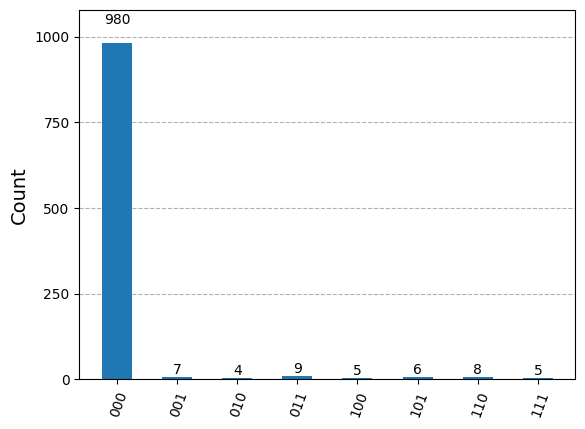

In [4]:
# Grover's algorithm
# Given a function f : {0,1}^n -> {0,1} such that for some input vector w,
# f(w) = 1 and for all x != w, f(x) = 0.
# The problem is to find w.

# Here we work with 3 qubits

# First we need a definition of f.

# Let's say f(0,0,0) = 1
# Try changing this to represent different search targets (you will need to change the definition of U, below)

# Then we need to define a unitary operator U on 3 qubits, such that
# U|x> = -|x> if f(x) = 1
# U|x> =  |x> if f(x) = 0

U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])

# Now construct the Grover diffusion operator

G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1],
    [1,-3, 1, 1, 1, 1, 1, 1],
    [1, 1,-3, 1, 1, 1, 1, 1],
    [1, 1, 1,-3, 1, 1, 1, 1],
    [1, 1, 1, 1,-3, 1, 1, 1],
    [1, 1, 1, 1, 1,-3, 1, 1],
    [1, 1, 1, 1, 1, 1,-3, 1],
    [1, 1, 1, 1, 1, 1, 1,-3]
]))

G = Operator(G_matrix)

# Build a circuit with the correct number of iterations hard-coded, in this case 2

grover = QuantumCircuit(3)

# To get the initial state, apply H to every qubit

grover.h(0)
grover.h(1)
grover.h(2)

# Repeatedly apply U then G

grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])

# What if we do too many iterations?

#grover.append(U,[0,1,2])
#grover.append(G,[0,1,2])

# Measure all the qubits - to do that, we don't need to introduce classical bits

grover.measure_all()

# Simulate and plot results

backend = BasicSimulator()
compiled = transpile(grover, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)